Import Essential Libraries 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

Load Data 

In [2]:
print("Loading genomic dataset...")
data = load_breast_cancer()
X = data.data          # 569 patients, 30 genomic features
y_true = data.target   # 0 = malignant, 1 = benign
feature_names = data.feature_names

print(f"Dataset shape : {X.shape}")
print(f"Classes       : {data.target_names}")
print(f"Features      : {list(feature_names[:5])} ...")

Loading genomic dataset...
Dataset shape : (569, 30)
Classes       : ['malignant' 'benign']
Features      : [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness')] ...


Preprocess

In [3]:
# Normalize to [0, 1]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Reduce to 2 features using PCA
# (quantum swap test needs 2-value vectors)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Normalize again to [0, 1] after PCA
X_pca = MinMaxScaler().fit_transform(X_pca)

print(f"\nAfter PCA     : {X_pca.shape}")
print(f"Variance kept : {sum(pca.explained_variance_ratio_)*100:.1f}%")

# Use first 30 patients for speed
# (swap test is slow — O(n²) quantum circuits)
limit = 30
X_use = X_pca[:limit]
y_use = y_true[:limit]


After PCA     : (569, 2)
Variance kept : 70.4%


Quantam Swap Test 

In [4]:
simulator = AerSimulator()

def normalize_vec(vec):
    """Normalize vector to unit length for quantum encoding"""
    norm = np.linalg.norm(vec)
    if norm == 0:
        return vec
    return vec / norm

def swap_test(v1, v2, shots=1024):
    """
    Quantum Swap Test — measures similarity between two quantum states
    
    Circuit: 3 qubits
      qubit 0 = ancilla (control)
      qubit 1 = state |v1>
      qubit 2 = state |v2>
    
    Steps:
      1. H gate on ancilla → superposition
      2. CSWAP (Fredkin gate) → entangle states
      3. H gate on ancilla again
      4. Measure ancilla
      
    Result: P(0) = 0.5 + 0.5 * |<v1|v2>|²
    Fidelity = 2*P(0) - 1 → ranges from 0 to 1
    """
    v1 = normalize_vec(v1)
    v2 = normalize_vec(v2)
    
    qc = QuantumCircuit(3, 1)
    
    # Encode data into quantum states
    qc.initialize(v1, 1)
    qc.initialize(v2, 2)
    
    # Swap test circuit
    qc.h(0)          # Hadamard on ancilla
    qc.cswap(0,1,2)  # Controlled SWAP
    qc.h(0)          # Hadamard again
    
    # Measure ancilla qubit
    qc.measure(0, 0)
    
    # Run on simulator
    compiled = transpile(qc, simulator)
    result = simulator.run(compiled, shots=shots).result()
    counts = result.get_counts()
    
    # Calculate fidelity
    p0 = counts.get('0', 0) / shots
    fidelity = max(0, min(1, 2 * p0 - 1))
    
    return fidelity

Similarity Matrix

In [5]:
print(f"\nComputing quantum similarity matrix for {limit} patients...")

similarity = np.zeros((limit, limit))

for i in range(limit):
    for j in range(limit):
        similarity[i, j] = swap_test(X_use[i], X_use[j])
    print(f"  Row {i+1}/{limit} done")

print("\nQuantum Similarity Matrix (first 5x5):")
print(np.round(similarity[:5, :5], 3))


Computing quantum similarity matrix for 30 patients...
(This runs one quantum circuit per patient pair — please wait)

  Row 1/30 done
  Row 2/30 done
  Row 3/30 done
  Row 4/30 done
  Row 5/30 done
  Row 6/30 done
  Row 7/30 done
  Row 8/30 done
  Row 9/30 done
  Row 10/30 done
  Row 11/30 done
  Row 12/30 done
  Row 13/30 done
  Row 14/30 done
  Row 15/30 done
  Row 16/30 done
  Row 17/30 done
  Row 18/30 done
  Row 19/30 done
  Row 20/30 done
  Row 21/30 done
  Row 22/30 done
  Row 23/30 done
  Row 24/30 done
  Row 25/30 done
  Row 26/30 done
  Row 27/30 done
  Row 28/30 done
  Row 29/30 done
  Row 30/30 done

Quantum Similarity Matrix (first 5x5):
[[1.    0.918 0.992 0.846 0.973]
 [0.918 1.    0.965 0.59  0.982]
 [0.979 0.961 1.    0.73  1.   ]
 [0.855 0.604 0.77  1.    0.764]
 [0.965 0.969 1.    0.742 1.   ]]


Similarities based Clustering 

In [6]:
# Convert similarity to distance
distance = 1 - similarity

# Quantum-informed clustering (KMeans on PCA features)
kmeans_quantum = KMeans(n_clusters=2, random_state=42, n_init=10)
quantum_labels = kmeans_quantum.fit_predict(X_use)

# Classical KMeans baseline (no quantum)
kmeans_classical = KMeans(n_clusters=2, random_state=42, n_init=10)
classical_labels = kmeans_classical.fit_predict(X_use)

# Evaluation
q_ari = adjusted_rand_score(y_use, quantum_labels)
c_ari = adjusted_rand_score(y_use, classical_labels)

print(f"\nQuantum Clustering ARI  : {q_ari:.4f}")
print(f"Classical KMeans ARI    : {c_ari:.4f}")
print("(ARI: 1.0 = perfect, 0.0 = random)")


Quantum Clustering ARI  : 0.0026
Classical KMeans ARI    : 0.0026
(ARI: 1.0 = perfect, 0.0 = random)


c:\Users\user\miniconda3\envs\myenvironment\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\user\miniconda3\envs\myenvironment\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Visvalization

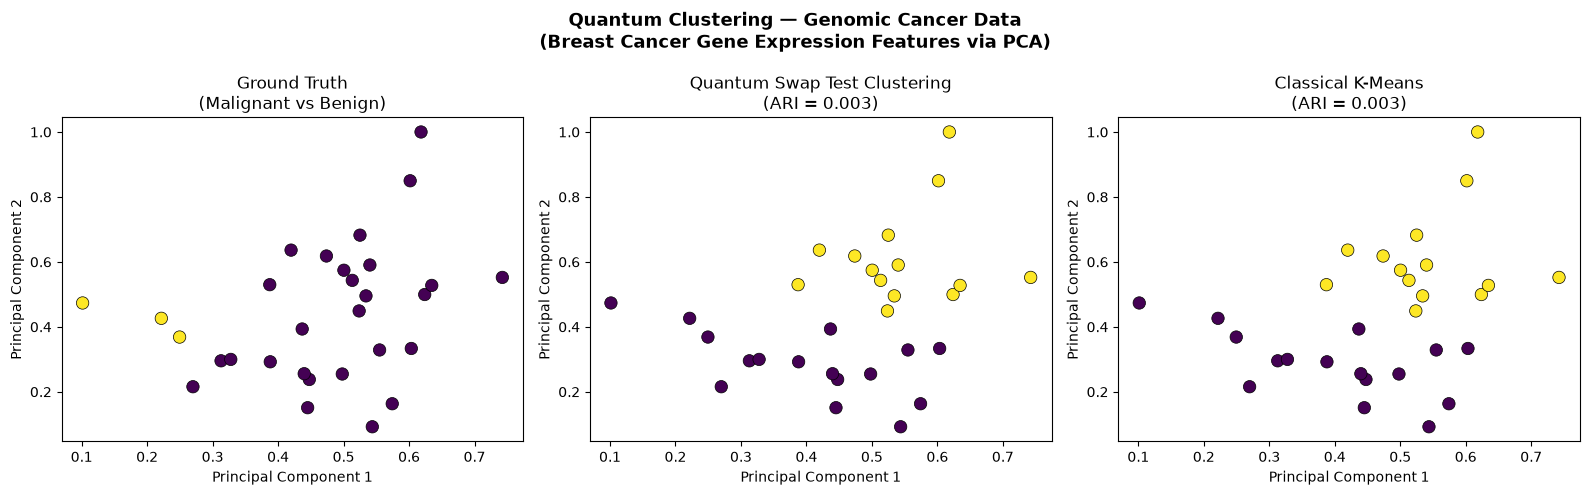


Saved: genomic_clustering_result.png


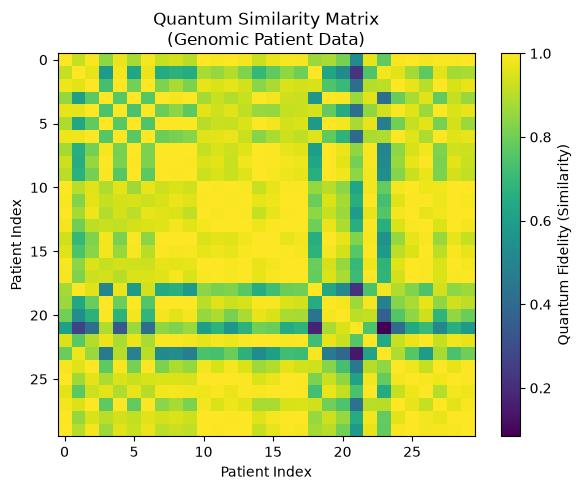

Saved: quantum_similarity_matrix.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "Quantum Clustering — Genomic Cancer Data\n"
    "(Breast Cancer Gene Expression Features via PCA)",
    fontsize=13, fontweight='bold'
)

# Plot 1 — Ground truth
axes[0].scatter(
    X_use[:, 0], X_use[:, 1],
    c=y_use, cmap='viridis', s=80, edgecolors='k', linewidths=0.5
)
axes[0].set_title("Ground Truth\n(Malignant vs Benign)")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")

# Plot 2 — Quantum clustering
axes[1].scatter(
    X_use[:, 0], X_use[:, 1],
    c=quantum_labels, cmap='viridis', s=80, edgecolors='k', linewidths=0.5
)
axes[1].set_title(f"Quantum Swap Test Clustering\n(ARI = {q_ari:.3f})")
axes[1].set_xlabel("Principal Component 1")
axes[1].set_ylabel("Principal Component 2")

# Plot 3 — Classical KMeans
axes[2].scatter(
    X_use[:, 0], X_use[:, 1],
    c=classical_labels, cmap='viridis', s=80, edgecolors='k', linewidths=0.5
)
axes[2].set_title(f"Classical K-Means\n(ARI = {c_ari:.3f})")
axes[2].set_xlabel("Principal Component 1")
axes[2].set_ylabel("Principal Component 2")

plt.tight_layout()
plt.savefig("genomic_clustering_result.png", dpi=150)
plt.show()
print("\nSaved: genomic_clustering_result.png")

# Plot 4 — Quantum Kernel Heatmap
plt.figure(figsize=(6, 5))
plt.imshow(similarity, cmap='viridis', aspect='auto')
plt.colorbar(label='Quantum Fidelity (Similarity)')
plt.title("Quantum Similarity Matrix\n(Genomic Patient Data)")
plt.xlabel("Patient Index")
plt.ylabel("Patient Index")
plt.tight_layout()
plt.savefig("quantum_similarity_matrix.png", dpi=150)
plt.show()
print("Saved: quantum_similarity_matrix.png")